# Portfolio optimization

Minimum-variance and maximum-Sharpe portfolios, and an efficient frontier, checked against `cvxpy`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import cuprox

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})
GPU = "#76B900"
REF = "#546778"

assert cuprox.__cuda_available__, (
    "This notebook must run against a CUDA build. Install with `pip install .` "
    "from the repository root; installing python/ alone does not build the "
    "extension."
)
from cuprox import _core
print(f"cuProx {cuprox.__version__} on {_core.get_device_name()}")

from cuprox.finance import Portfolio

cuProx 0.2.0 on NVIDIA RTX A6000


## Data

Synthetic daily returns for eight assets with different drifts, so the results are reproducible without a data dependency.

In [2]:
rng = np.random.default_rng(7)
n_assets, n_days = 8, 756
factor = rng.standard_normal(n_days)
beta = rng.uniform(0.4, 1.4, n_assets)
returns = (0.01 * np.outer(factor, beta)
           + 0.012 * rng.standard_normal((n_days, n_assets)))
returns += np.linspace(-0.0002, 0.0009, n_assets)

port = Portfolio(returns)
print("annualised expected returns:", np.round(port.expected_returns, 4))

annualised expected returns: [-0.0022 -0.0018 -0.0006 -0.0009  0.0008  0.0001 -0.0004 -0.0005]


## Two portfolios

In [3]:
mv = port.optimize(method="min_variance")
ms = port.optimize(method="max_sharpe")

for name, r in (("min variance", mv), ("max sharpe", ms)):
    print(f"{name:>13}  return {r.expected_return:7.4f}  vol {r.volatility:6.4f}  sharpe {r.sharpe_ratio:6.3f}  [{r.status}]")

assert mv.status == "optimal" and ms.status == "optimal"
# Weights are a portfolio: non-negative and summing to one.
for r in (mv, ms):
    assert abs(r.weights.sum() - 1.0) < 1e-4
    assert np.all(r.weights >= -1e-6)
# Each optimum must be best at its own objective.
assert mv.volatility <= ms.volatility + 1e-6
assert ms.sharpe_ratio >= mv.sharpe_ratio - 1e-6

 min variance  return -0.1062  vol 0.1386  sharpe -0.766  [optimal]
   max sharpe  return  0.2017  vol 0.2090  sharpe  0.965  [optimal]


## Checking the frontier against cvxpy

For a set of target returns, solve `min wᵀΣw s.t. μᵀw = target, Σw = 1, w ≥ 0` with both cuProx and cvxpy and compare the resulting volatilities.

In [4]:
import cvxpy as cp

mu, cov = port.expected_returns, port.covariance
span = mu.max() - mu.min()
targets = np.linspace(mu.min() + 0.05 * span, mu.max() - 0.05 * span, 9)
periods = 252  # trading days, the annualisation Portfolio applies

vol_gpu, vol_ref = [], []
for t in targets:
    r = port.optimize(method="target_return", target_return=float(t))
    vol_gpu.append(r.volatility)
    assert abs(r.expected_return - t * periods) < 1e-3 * max(abs(t * periods), 1.0)

    w = cp.Variable(len(mu))
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, cp.psd_wrap(cov))),
                      [cp.sum(w) == 1, w >= 0, mu @ w == t])
    prob.solve(solver=cp.CLARABEL)
    # PortfolioResult reports annualised figures; the covariance here is
    # per-period, so annualise the reference before comparing.
    vol_ref.append(float(np.sqrt(prob.value * periods)))

vol_gpu, vol_ref = np.array(vol_gpu), np.array(vol_ref)
rel = np.abs(vol_gpu - vol_ref) / vol_ref
print(f"frontier volatility, max relative difference vs cvxpy: {rel.max():.2e}")
assert rel.max() < 5e-3

frontier volatility, max relative difference vs cvxpy: 8.78e-04


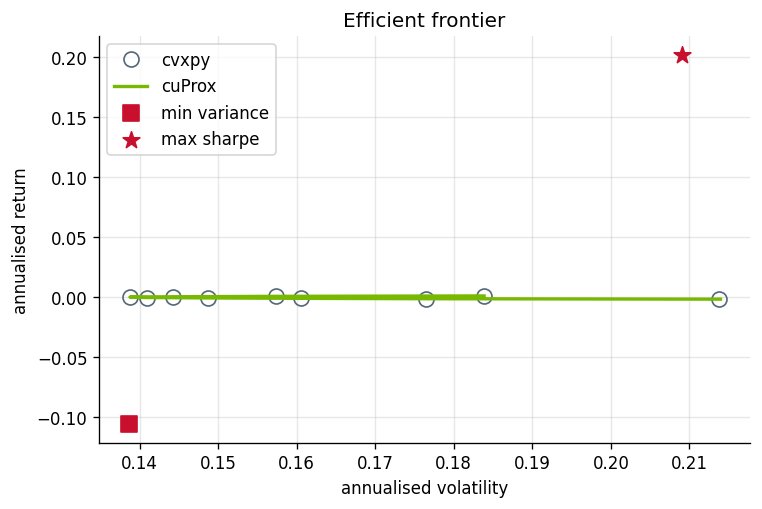

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.4))
ax.plot(vol_ref, targets, "o", ms=9, mfc="none", color=REF, label="cvxpy")
ax.plot(vol_gpu, targets, "-", lw=2, color=GPU, label="cuProx")
ax.scatter(mv.volatility, mv.expected_return, s=90, marker="s",
           color="#C8102E", zorder=5, label="min variance")
ax.scatter(ms.volatility, ms.expected_return, s=110, marker="*",
           color="#C8102E", zorder=5, label="max sharpe")
ax.set_xlabel("annualised volatility")
ax.set_ylabel("annualised return")
ax.set_title("Efficient frontier")
ax.legend()
fig.savefig("portfolio_frontier.png")
plt.show()